In [2]:
import math 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from itertools import cycle
import matplotlib as mpl
import matplotlib.colors as mcolors
from matplotlib.pyplot import cm
import glob
import os

import warnings
warnings.filterwarnings("ignore", message="Workbook contains no default style")
#!pip install xlrd
#!pip install openpyxl

#!pip install mplcursors

#!pip install xlsxwriter
pi = (math. pi)


e = (math.e )



%matplotlib notebook
from pylab import rcParams
rcParams['figure.figsize'] =10,8

def define_figure(xlabel="X", ylabel="Y"):
    fig = plt.figure(figsize=(8,6), dpi= 80, facecolor='w', edgecolor='k')
    ax = plt.subplot(111)
    ax.grid(b=True, which='major', axis='both', color='#808080', linestyle='--')
    ax.set_xlabel(xlabel,size=20)
    ax.set_ylabel(ylabel,size=20)
    plt.tick_params(axis='both',labelsize=20)
    return ax

plt.rcParams["font.family"] = "Calibri"

In [3]:
# -----------------------------
# Cell: Extract Cycle 1 Step 2 and convert TotalTime to seconds
# -----------------------------


# Load the data
data1 = pd.read_excel(
    'Peak_Feb26_Run003.xlsx',
    sheet_name='DATA',
    usecols='A,B,C,D,E,F,G,H,I,J,K,L,M,N,O,P,Q,R,S,T,U,V,W,X,Y,Z,AA,AB,AC,AD,AE,AF,AG,AH,AI,AJ,AK,AL,AM,AO,AP,AQ,AR,AS,AT,AU,AV,AW,AX,AY,AZ,BA,BB,BC,BD,BE,BF,BG',
    names=['Timstamp','Time_s','OCV','Heater_V','Heater_A','Heater_W','TC1','TC2','TC3','TC4','TC5','TC6','TC7','TC8','TC9','TC10','TC11','TC12','TC13','TC14','TC15','TC16','TC17','TC18','TC19',
           'TC20','TC21','TC22','TC23','TC24','TC25','TC26','TC27','TC28','TC29','TC30','TC31','TC32','TC33','TC34','TC35','TC36','TC37','TC38','TC39','TC40','TC41','TC42','TC43','TC44','TC45',
           'TC46','TC47','TC48','TC_Heater','TC_QRcode','TC_abm','TC_Ex_NoFoam','TC_Ex_Foam'],
    engine='openpyxl'
)

print(data1[['Time_s','OCV','TC1','TC47']])

       Time_s       OCV         TC1        TC47
0         0.0  3.235124   24.869531   24.686461
1         0.1  3.235122   24.882449   24.695274
2         0.2  3.235119   24.891549   24.688206
3         0.3  3.235118   24.858001   24.694476
4         0.4  3.235122   24.871114   24.675872
...       ...       ...         ...         ...
72235  7223.5  0.000075  155.131924  146.691528
72236  7223.6  0.000074  155.178792  146.682376
72237  7223.7  0.000074  155.156378  146.710229
72238  7223.8  0.000082  155.157873  146.676949
72239  7223.9  0.000075  155.145494  146.683712

[72240 rows x 4 columns]


C:\Users\DanWindsor\AppData\Local\Temp\ipykernel_7012\2946726871.py:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis', n_other)


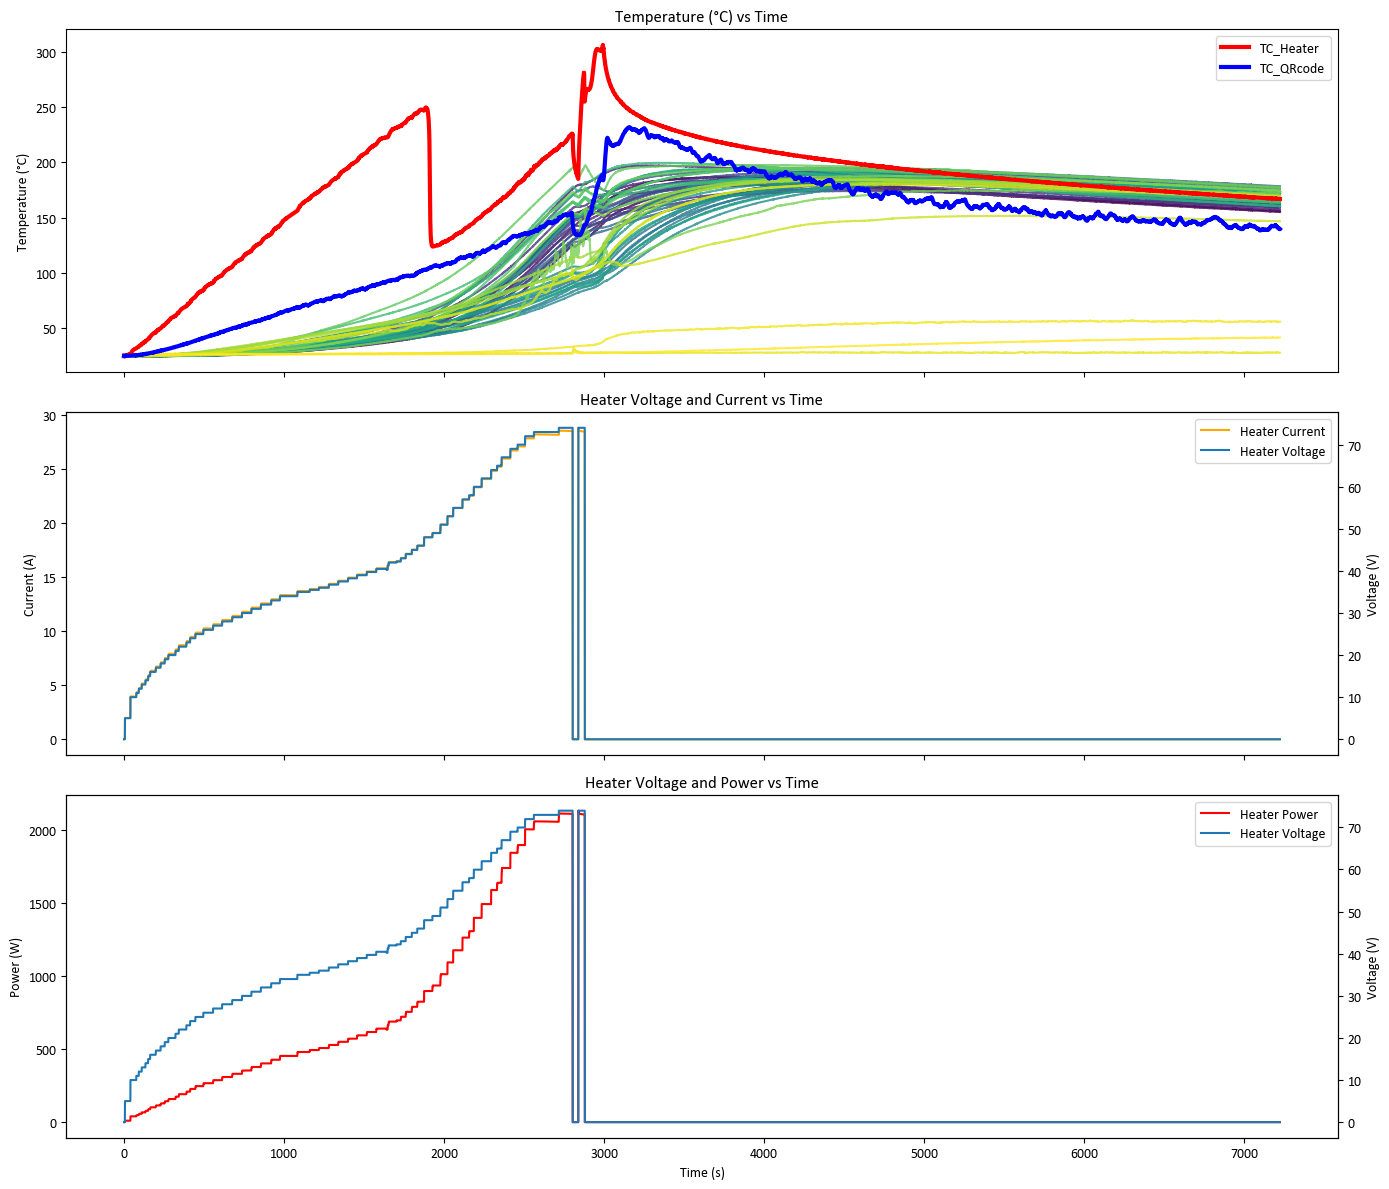

In [4]:
# -----------------------------
# Cell: Three-Panel Plot (TC_Heater Red, TC_QRcode Blue, Other TCs Color Map)
# -----------------------------

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
%matplotlib inline

# Ensure numeric time
data1['Time_s'] = pd.to_numeric(data1['Time_s'], errors='coerce')

# Identify thermocouple columns
tc_cols = [col for col in data1.columns if col.startswith('TC')]

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# ============================================================
# Panel 1: Temperature vs Time (Color map for other TCs)
# ============================================================

ax1_left = axes[0]

# Select TCs to color-map (excluding bolded)
other_tcs = [tc for tc in tc_cols if tc not in ['TC_Heater', 'TC_QRcode']]
n_other = len(other_tcs)

# Create colormap
cmap = cm.get_cmap('viridis', n_other)

# Plot other TCs with colormap
for i, tc in enumerate(other_tcs):
    ax1_left.plot(data1['Time_s'], data1[tc],
                  color=cmap(i),
                  alpha=0.8,
                  linewidth=1.5,
                  zorder=1)

# Bold TC_Heater in RED
bold_lines = []
bold_labels = []

if 'TC_Heater' in data1.columns:
    line_heater, = ax1_left.plot(
        data1['Time_s'],
        data1['TC_Heater'],
        linewidth=3,
        alpha=1.0,
        color='red',
        zorder=10,
        label='TC_Heater'
    )
    bold_lines.append(line_heater)
    bold_labels.append('TC_Heater')

# Bold TC_QRcode in BLUE
if 'TC_QRcode' in data1.columns:
    line_qrcode, = ax1_left.plot(
        data1['Time_s'],
        data1['TC_QRcode'],
        linewidth=3,
        alpha=1.0,
        color='blue',
        zorder=10,
        label='TC_QRcode'
    )
    bold_lines.append(line_qrcode)
    bold_labels.append('TC_QRcode')

ax1_left.set_ylabel('Temperature (°C)')
ax1_left.set_title('Temperature (°C) vs Time')
ax1_left.grid(False)

# Legend only for bolded TCs
if bold_lines:
    ax1_left.legend(bold_lines, bold_labels, loc='best')


# ============================================================
# Panel 2: Heater Current (left) + Heater Voltage (right)
# ============================================================

ax2_left = axes[1]
ax2_right = ax2_left.twinx()

line_current, = ax2_left.plot(
    data1['Time_s'], 
    data1['Heater_A'], 
    label='Heater Current',
    color='orange'
)

line_voltage_2, = ax2_right.plot(
    data1['Time_s'], 
    data1['Heater_V'], 
    label='Heater Voltage'
)

ax2_left.set_ylabel('Current (A)')
ax2_right.set_ylabel('Voltage (V)')
ax2_left.set_title('Heater Voltage and Current vs Time')
ax2_left.grid(False)

ax2_left.legend([line_current, line_voltage_2],
                ['Heater Current', 'Heater Voltage'],
                loc='best')


# ============================================================
# Panel 3: Heater Power (left) + Heater Voltage (right)
# ============================================================

ax3_left = axes[2]
ax3_right = ax3_left.twinx()

line_power, = ax3_left.plot(
    data1['Time_s'], 
    data1['Heater_W'], 
    label='Heater Power',
    color='r'
)

line_voltage_3, = ax3_right.plot(
    data1['Time_s'], 
    data1['Heater_V'], 
    label='Heater Voltage'
)

ax3_left.set_ylabel('Power (W)')
ax3_right.set_ylabel('Voltage (V)')
ax3_left.set_title('Heater Voltage and Power vs Time')
ax3_left.grid(False)

ax3_left.legend([line_power, line_voltage_3],
                ['Heater Power', 'Heater Voltage'],
                loc='best')

axes[2].set_xlabel('Time (s)')

plt.tight_layout()

plt.savefig('EnergyRemaining_Veken_170Ah_HT-B_Ensemble_v1.png',dpi=300)

plt.show()

In [5]:
# -----------------------------
# Cell: Fixture Plate → TC Mapping (Plate-Centric)
# -----------------------------

# Plate-centric mapping
# You can easily edit each plate and assign TCs
plate_tc_map = {
    'Plate_A': ['TC1', 'TC2', 'TC3', 'TC4', 'TC5', 'TC6', 'TC7', 'TC8', 'TC9'],
    'Plate_H': ['TC10', 'TC11', 'TC12', 'TC13', 'TC14', 'TC15', 'TC16', 'TC17', 'TC18'],
    'Plate_G': ['TC19', 'TC20', 'TC21'],
    'Plate_J': ['TC22', 'TC23', 'TC24'],
    'Plate_I': ['TC25','TC26','TC27'],
    'Plate_B': ['TC28','TC29','TC30'],
    'Plate_E': ['TC31','TC32','TC33','TC34','TC35','TC36'],
    'Plate_D': ['TC37','TC38','TC39','TC40','TC41','TC42'],
    'Plate_C': ['TC43','TC44','TC45'],
    'Plate_F': ['TC46','TC47','TC48'],
    # Add more plates as needed
    'Heater_Location': ['TC_Heater'],
    'QR_Location': ['TC_QRcode'],
    'ABM_Location': ['TC_abm'],
    'Fixture_Ex_Nofoam': ['TC_Ex_NoFoam'],
    'Fixture_Ex_Foam': ['TC_Ex_Foam']
}

# Convert to DataFrame for easy viewing
import pandas as pd

# Flatten the mapping for a table format: Plate | TC
records = []
for plate, tcs in plate_tc_map.items():
    for tc in tcs:
        records.append({'Fixture_Plate': plate, 'TC': tc})

plate_mapping_df = pd.DataFrame(records)

# Display the plate-centric mapping
plate_mapping_df

,Fixture_Plate,TC
0,Plate_A,TC1
1,Plate_A,TC2
2,Plate_A,TC3
3,Plate_A,TC4
4,Plate_A,TC5
5,Plate_A,TC6
6,Plate_A,TC7
7,Plate_A,TC8
8,Plate_A,TC9
9,Plate_H,TC10


C:\Users\DanWindsor\AppData\Local\Temp\ipykernel_7012\316419103.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20', n_plates)  # tab20 has 20 distinct colors


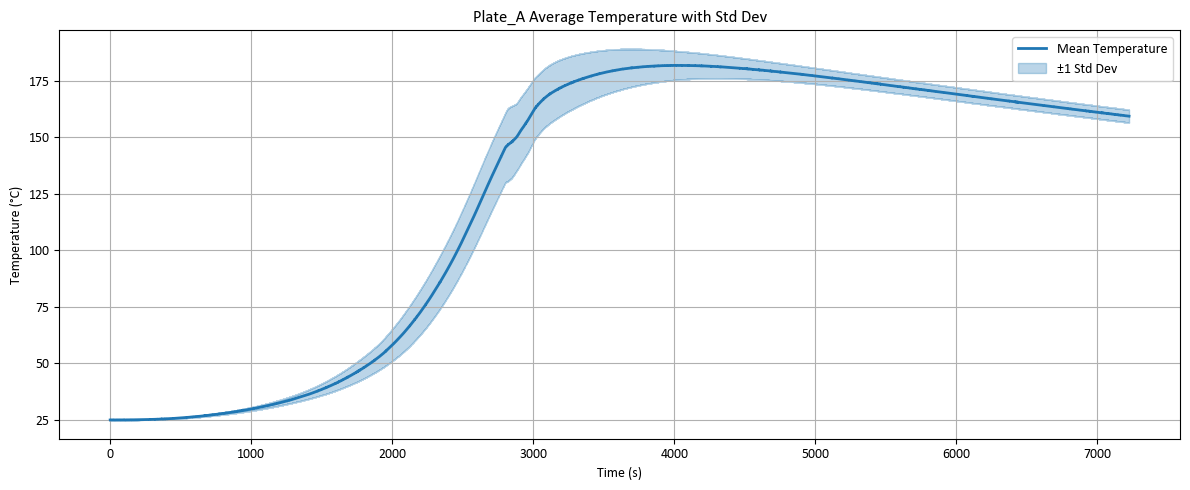

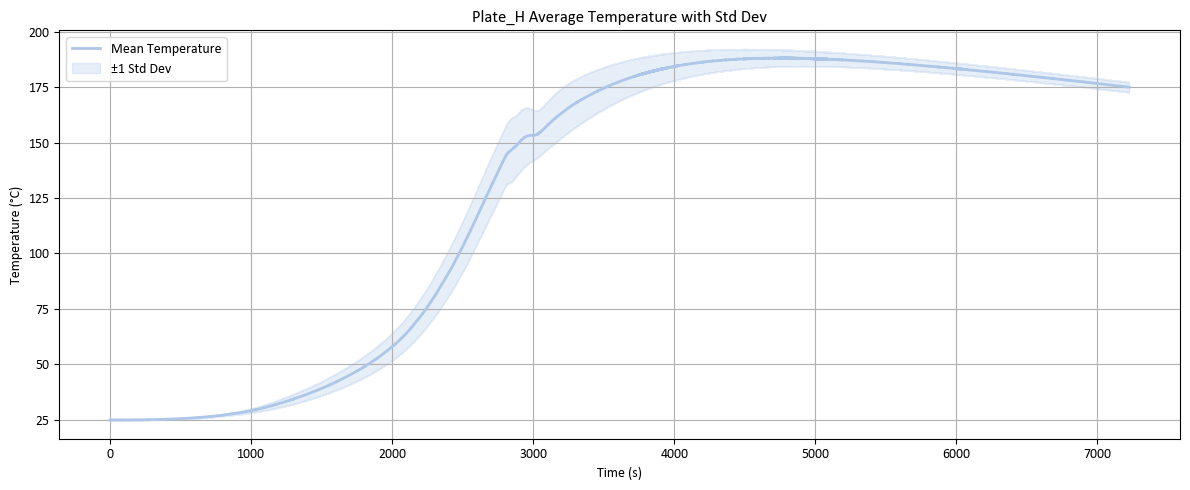

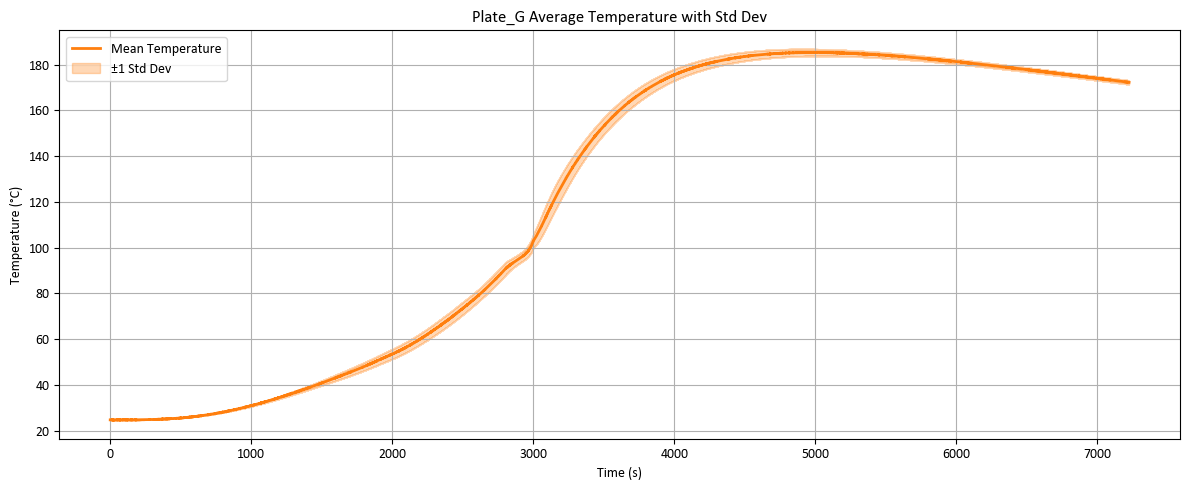

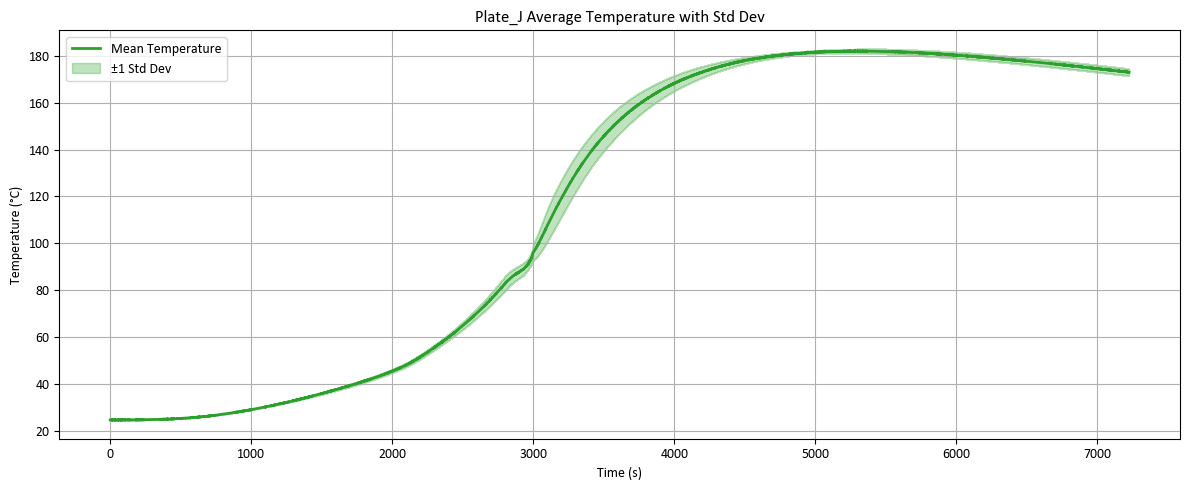

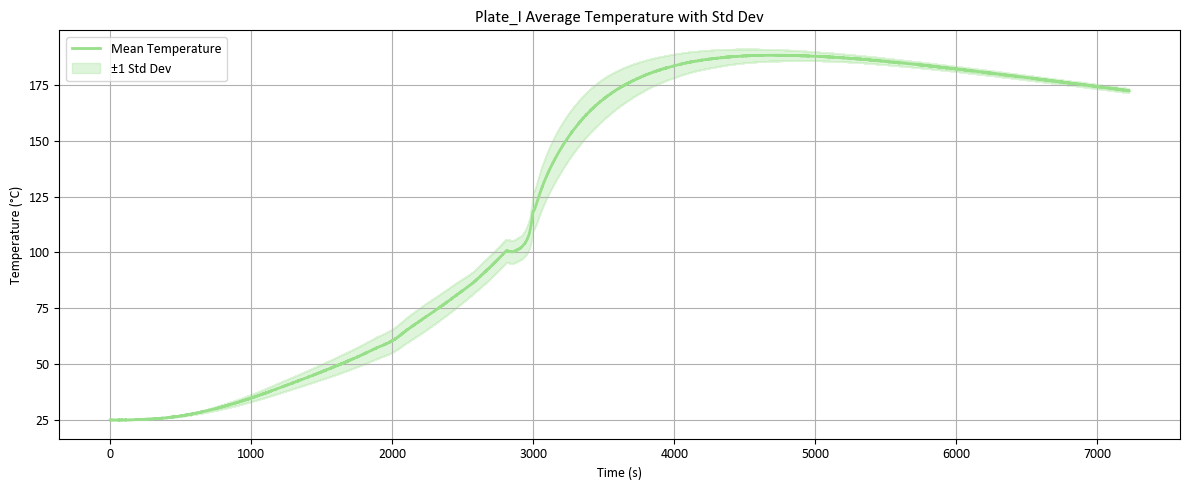

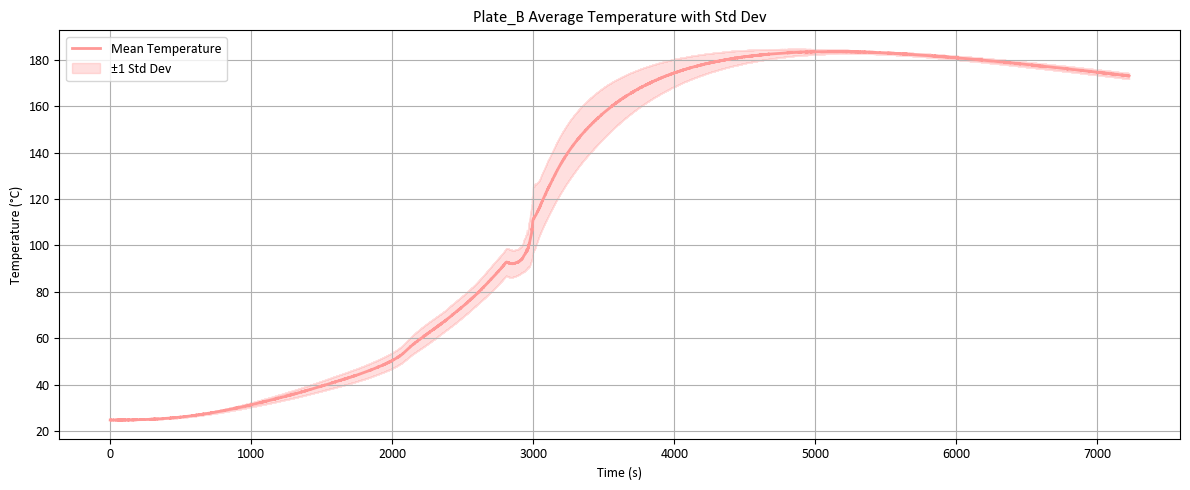

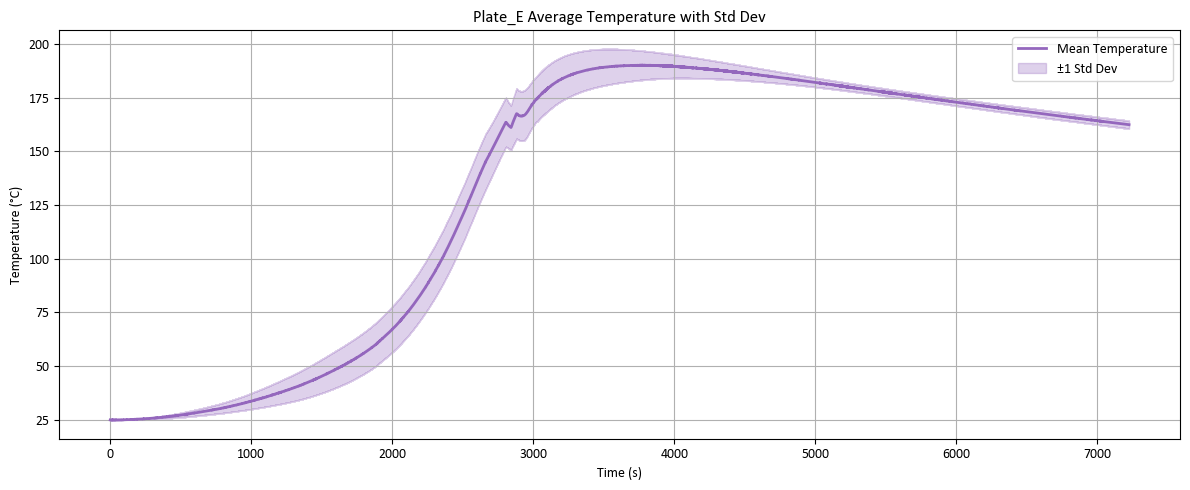

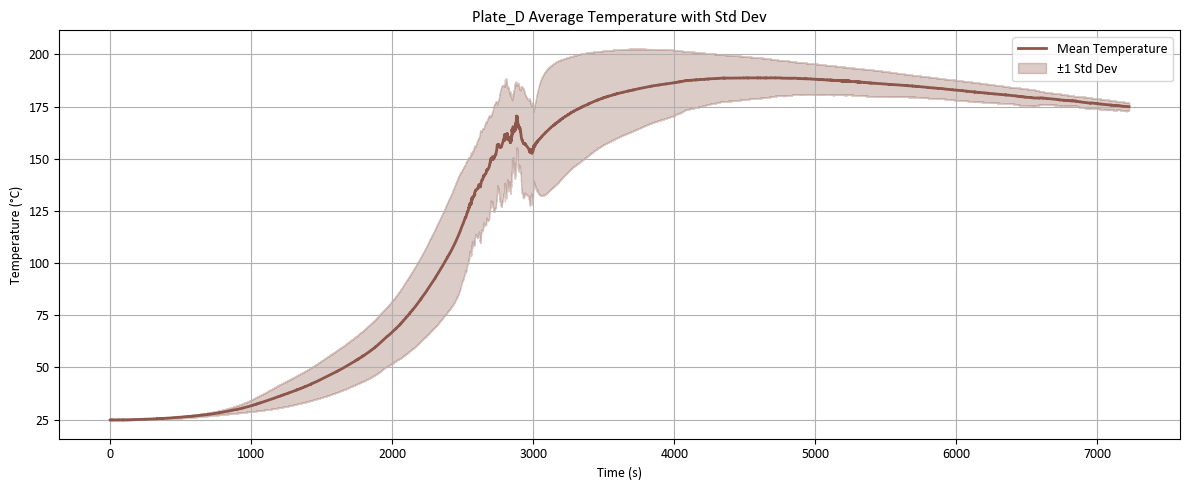

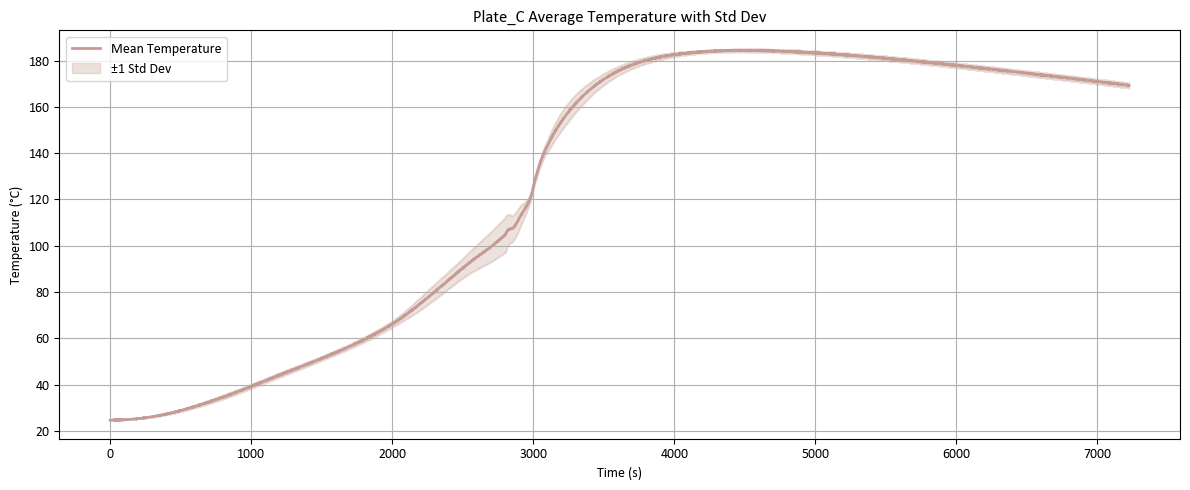

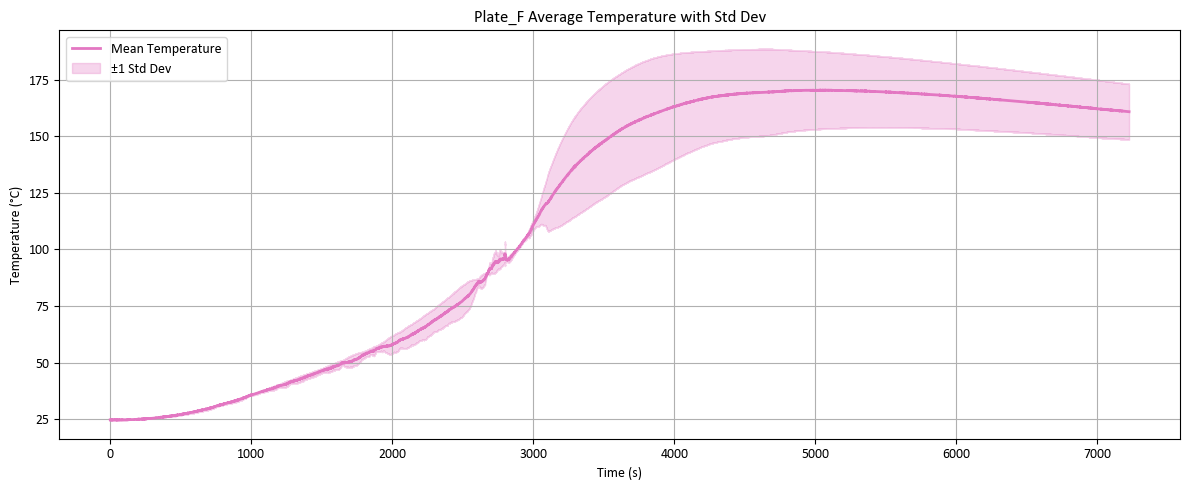

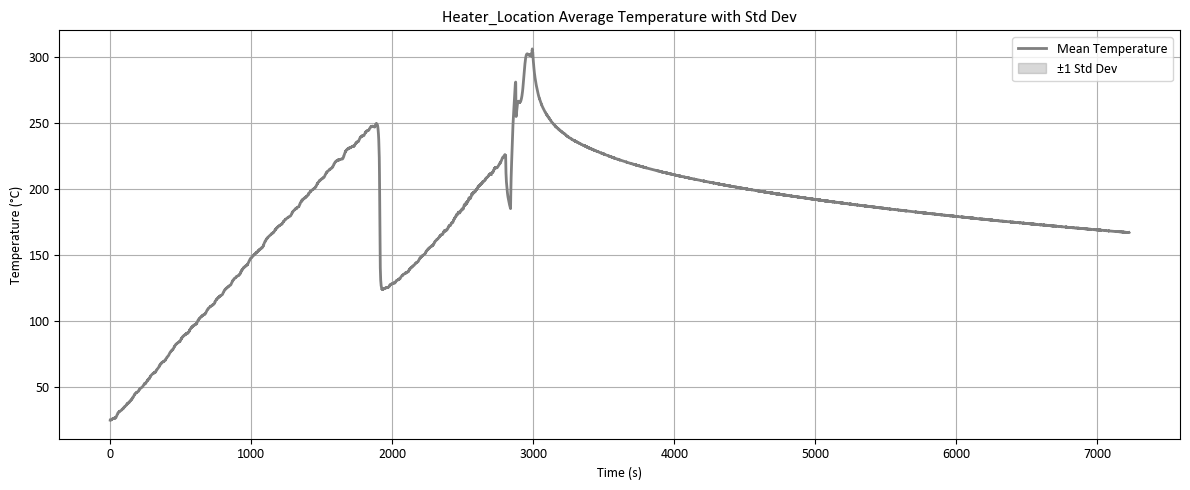

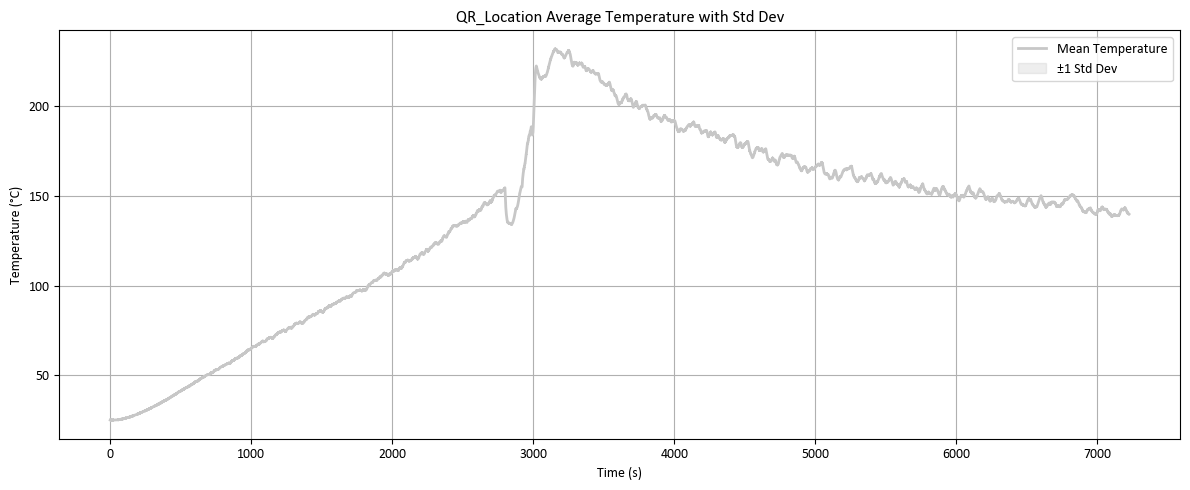

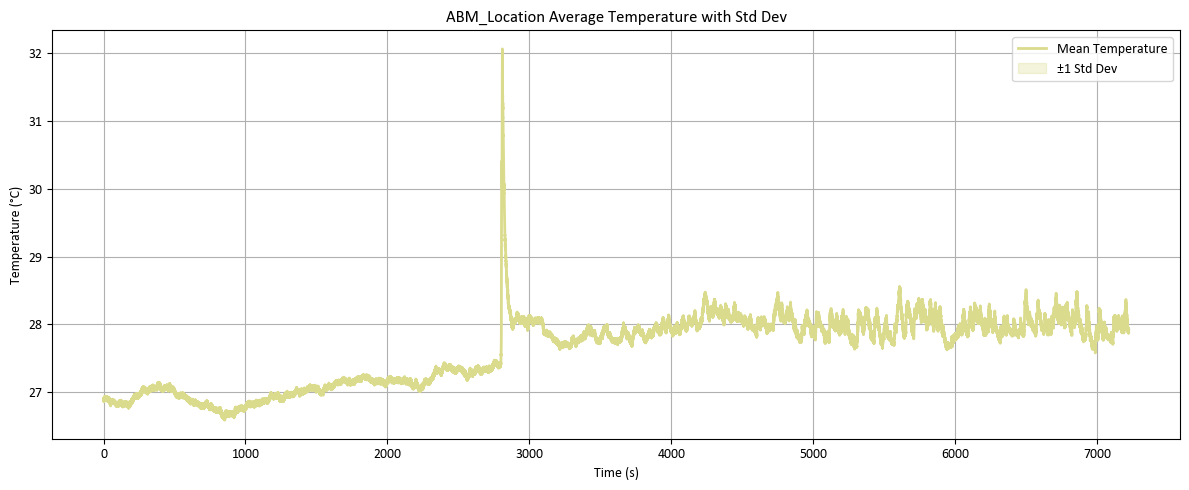

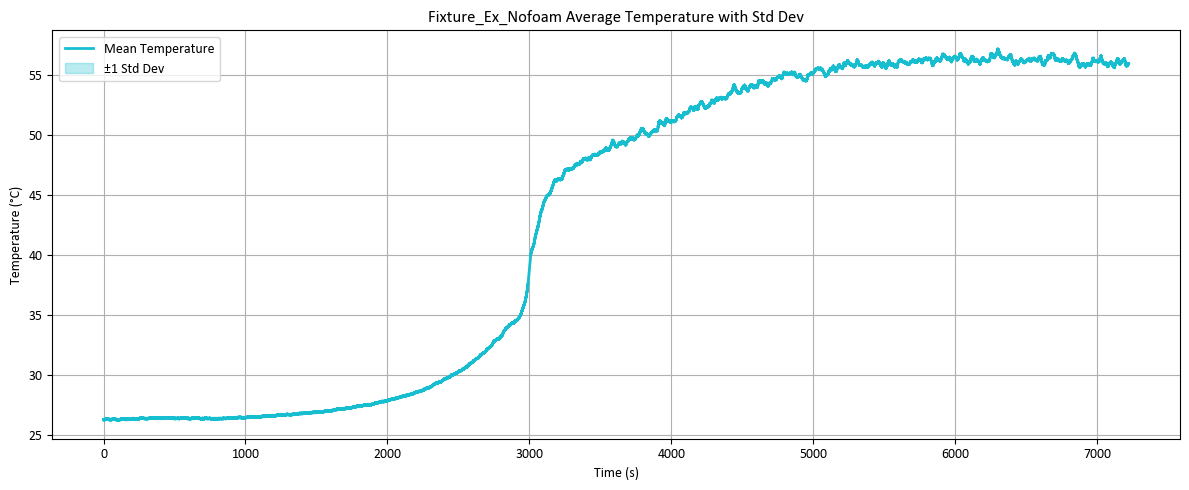

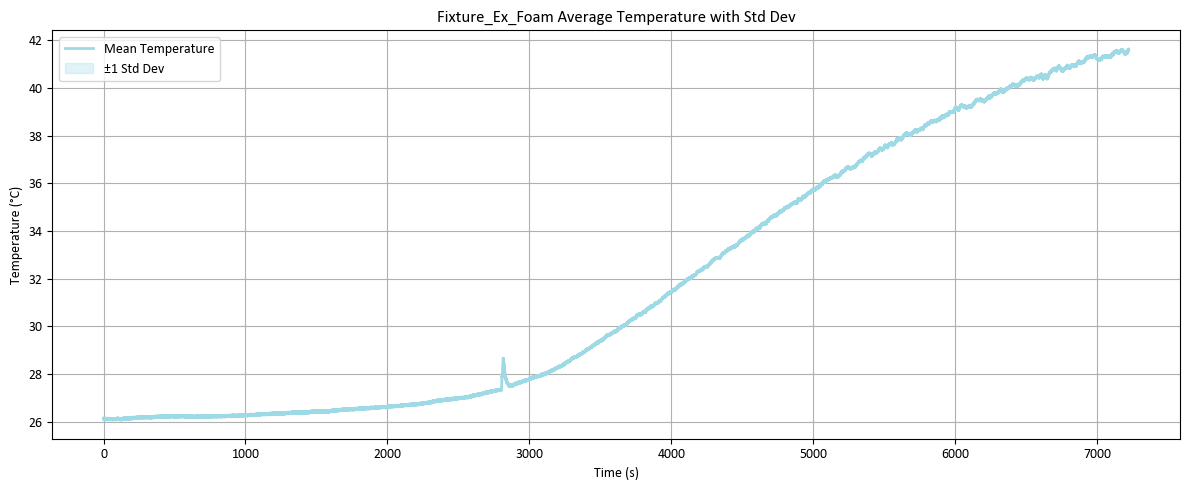

In [6]:
# -----------------------------
# Cell: Plot Average Temperature per Plate with Plate-Specific Colors
# -----------------------------

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Ensure numeric time
data1['Time_s'] = pd.to_numeric(data1['Time_s'], errors='coerce')

# Generate a colormap for the plates
plate_names = list(plate_tc_map.keys())
n_plates = len(plate_names)
cmap = cm.get_cmap('tab20', n_plates)  # tab20 has 20 distinct colors

# Assign a color to each plate
plate_colors = {plate: cmap(i) for i, plate in enumerate(plate_names)}

# Loop over each plate and plot
for plate, tcs in plate_tc_map.items():
    # Check which TCs actually exist in the dataframe
    valid_tcs = [tc for tc in tcs if tc in data1.columns]
    if len(valid_tcs) == 0:
        continue  # skip plates with no valid TCs
    
    # Extract TC data
    tc_data = data1[valid_tcs]
    
    # Compute mean and standard deviation across TCs
    mean_trace = tc_data.mean(axis=1)
    std_trace = tc_data.std(axis=1)
    
    # Get the color for this plate
    color = plate_colors[plate]
    
    # Create figure for this plate
    plt.figure(figsize=(12, 5))
    
    # Plot mean trace
    plt.plot(data1['Time_s'], mean_trace, color=color, linewidth=2, label='Mean Temperature')
    
    # Plot standard deviation band
    plt.fill_between(
        data1['Time_s'],
        mean_trace - std_trace,
        mean_trace + std_trace,
        color=color,
        alpha=0.3,
        label='±1 Std Dev'
    )
    
    plt.title(f'{plate} Average Temperature with Std Dev')
    plt.xlabel('Time (s)')
    plt.ylabel('Temperature (°C)')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [7]:
# -----------------------------
# Cell: Calculate Max & Initial Temperature per Plate
# -----------------------------

import pandas as pd

# Dictionaries to store results
plate_max_temp = {}
plate_initial_temp = {}

# Loop over each plate
for plate, tcs in plate_tc_map.items():
    # Filter TCs that actually exist in the dataframe
    valid_tcs = [tc for tc in tcs if tc in data1.columns]
    
    if len(valid_tcs) == 0:
        print(f"Skipping {plate}: No valid TCs found.")
        continue
    
    # Calculate max temperature for each TC
    max_temps = data1[valid_tcs].max()
    avg_max_temp = max_temps.mean()
    plate_max_temp[plate] = avg_max_temp
    
    # Calculate average initial temperature (first row)
    initial_temps = data1[valid_tcs].iloc[0]
    avg_initial_temp = initial_temps.mean()
    plate_initial_temp[plate] = avg_initial_temp

# Combine results into a DataFrame
plate_temp_summary_df = pd.DataFrame({
    'Plate': list(plate_max_temp.keys()),
    'Average_Max_Temperature': list(plate_max_temp.values()),
    'Average_Initial_Temperature': list(plate_initial_temp.values())
})

# Sort by plate for readability
plate_temp_summary_df = plate_temp_summary_df.sort_values('Plate').reset_index(drop=True)

# Display the table
plate_temp_summary_df

,Plate,Average_Max_Temperature,Average_Initial_Temperature
0,ABM_Location,32.060282,26.892044
1,Fixture_Ex_Foam,41.641368,26.132877
2,Fixture_Ex_Nofoam,57.179458,26.284246
3,Heater_Location,306.060066,24.672387
4,Plate_A,182.911781,24.833871
5,Plate_B,183.697837,24.866436
6,Plate_C,184.476706,24.745897
7,Plate_D,190.397774,24.869902
8,Plate_E,190.949138,24.878403
9,Plate_F,170.893040,24.663997


In [8]:
# -----------------------------
# Cell: Calculate Max & Initial Temperature per Plate
# -----------------------------
import pandas as pd

# -----------------------------
# CONFIGURATION
# Set the timepoint for initial temperature calculation.
# Options:
#   - Integer (row index): e.g., 0 for the first row, 5 for the 6th row
#   - Float/value (time-based): e.g., 10.0 — will select the row nearest to that time value
#   - Set use_time_column = True to match against a time column, False to use row index
# -----------------------------
initial_temp_timepoint = 2879.2        # <-- set your desired timepoint here
use_time_column = True           # <-- set to True if matching against a time value in a column
time_column_name = 'Time_s'         # <-- name of your time column (only used if use_time_column = True)

# Resolve the row to use for initial temperature
if use_time_column:
    if time_column_name not in data1.columns:
        raise ValueError(f"Time column '{time_column_name}' not found in dataframe.")
    nearest_idx = (data1[time_column_name] - initial_temp_timepoint).abs().idxmin()
    initial_row = data1.loc[[nearest_idx]]
else:
    initial_row = data1.iloc[[initial_temp_timepoint]]

# Dictionaries to store results
plate_max_temp = {}
plate_initial_temp = {}

# Loop over each plate
for plate, tcs in plate_tc_map.items():
    # Filter TCs that actually exist in the dataframe
    valid_tcs = [tc for tc in tcs if tc in data1.columns]
    
    if len(valid_tcs) == 0:
        print(f"Skipping {plate}: No valid TCs found.")
        continue
    
    # Calculate max temperature for each TC
    max_temps = data1[valid_tcs].max()
    avg_max_temp = max_temps.mean()
    plate_max_temp[plate] = avg_max_temp
    
    # Calculate average initial temperature at the specified timepoint
    initial_temps = initial_row[valid_tcs].iloc[0]
    avg_initial_temp = initial_temps.mean()
    plate_initial_temp[plate] = avg_initial_temp

# Combine results into a DataFrame
plate_temp_summary_df = pd.DataFrame({
    'Plate': list(plate_max_temp.keys()),
    'Average_Max_Temperature': list(plate_max_temp.values()),
    'Average_Initial_Temperature': list(plate_initial_temp.values())
})

# Sort by plate for readability
plate_temp_summary_df = plate_temp_summary_df.sort_values('Plate').reset_index(drop=True)

# Display the table
plate_temp_summary_df

,Plate,Average_Max_Temperature,Average_Initial_Temperature
0,ABM_Location,32.060282,27.974819
1,Fixture_Ex_Foam,41.641368,27.512850
2,Fixture_Ex_Nofoam,57.179458,34.353144
3,Heater_Location,306.060066,256.704161
4,Plate_A,182.911781,149.995181
5,Plate_B,183.697837,92.602934
6,Plate_C,184.476706,109.582350
7,Plate_D,190.397774,168.466655
8,Plate_E,190.949138,167.263908
9,Plate_F,170.893040,99.636922


In [9]:
# -----------------------------
# Cell: Calculate Max & Initial Temperature per Plate
# -----------------------------
import pandas as pd

# -----------------------------
# CONFIGURATION
# Set the timepoint for initial temperature calculation.
# Options:
#   - Integer (row index): e.g., 0 for the first row, 5 for the 6th row
#   - Float/value (time-based): e.g., 10.0 — will select the row nearest to that time value
#   - Set use_time_column = True to match against a time column, False to use row index
# -----------------------------
initial_temp_timepoint = 2879.2        # <-- set your desired timepoint here
use_time_column = True                 # <-- set to True if matching against a time value in a column
time_column_name = 'Time_s'           # <-- name of your time column (only used if use_time_column = True)

# -----------------------------
# MAX TEMPERATURE TIME WINDOW
# Set the start and end time for the window over which avg max temp is calculated.
# Both values are matched against time_column_name (same column as above).
# Set max_window_start = None to start from the beginning of the data.
# Set max_window_end = None to use the end of the data.
# -----------------------------
max_window_start = 6000.0             # <-- start of time window (or None)
max_window_end   = 7000.0             # <-- end of time window (or None)

# -----------------------------
# Resolve the row to use for initial temperature
# -----------------------------
if use_time_column:
    if time_column_name not in data1.columns:
        raise ValueError(f"Time column '{time_column_name}' not found in dataframe.")
    nearest_idx = (data1[time_column_name] - initial_temp_timepoint).abs().idxmin()
    initial_row = data1.loc[[nearest_idx]]
else:
    initial_row = data1.iloc[[initial_temp_timepoint]]

# -----------------------------
# Resolve the time window for max temperature
# -----------------------------
if use_time_column and time_column_name in data1.columns:
    window_mask = pd.Series([True] * len(data1), index=data1.index)
    if max_window_start is not None:
        window_mask &= data1[time_column_name] >= max_window_start
    if max_window_end is not None:
        window_mask &= data1[time_column_name] <= max_window_end
    data_window = data1[window_mask]
else:
    data_window = data1  # fallback: use all data

print(f"Max temp window: {len(data_window)} rows "
      f"({data_window[time_column_name].min():.1f}s – {data_window[time_column_name].max():.1f}s)")

# -----------------------------
# Dictionaries to store results
# -----------------------------
plate_max_temp = {}
plate_initial_temp = {}

# Loop over each plate
for plate, tcs in plate_tc_map.items():
    # Filter TCs that actually exist in the dataframe
    valid_tcs = [tc for tc in tcs if tc in data1.columns]

    if len(valid_tcs) == 0:
        print(f"Skipping {plate}: No valid TCs found.")
        continue

    # Calculate max temperature for each TC within the time window
    max_temps = data_window[valid_tcs].max()
    avg_max_temp = max_temps.mean()
    plate_max_temp[plate] = avg_max_temp

    # Calculate average initial temperature at the specified timepoint
    initial_temps = initial_row[valid_tcs].iloc[0]
    avg_initial_temp = initial_temps.mean()
    plate_initial_temp[plate] = avg_initial_temp

# Combine results into a DataFrame
plate_temp_summary_df = pd.DataFrame({
    'Plate': list(plate_max_temp.keys()),
    'Average_Max_Temperature': list(plate_max_temp.values()),
    'Average_Initial_Temperature': list(plate_initial_temp.values())
})

# Sort by plate for readability
plate_temp_summary_df = plate_temp_summary_df.sort_values('Plate').reset_index(drop=True)

# Display the table
plate_temp_summary_df

Max temp window: 10000 rows (6000.0s – 6999.9s)


,Plate,Average_Max_Temperature,Average_Initial_Temperature
0,ABM_Location,28.514429,27.974819
1,Fixture_Ex_Foam,41.409111,27.512850
2,Fixture_Ex_Nofoam,57.179458,34.353144
3,Heater_Location,179.059282,256.704161
4,Plate_A,169.168578,149.995181
5,Plate_B,180.821786,92.602934
6,Plate_C,177.926718,109.582350
7,Plate_D,182.984920,168.466655
8,Plate_E,172.887906,167.263908
9,Plate_F,167.654146,99.636922


In [10]:
# -----------------------------
# Cell: Export Average Temperature per Plate to CSV
# -----------------------------

import pandas as pd
import os

# Folder to save CSV files
csv_folder = "Plate_Temperature_VekenHT-B_CSVs"
os.makedirs(csv_folder, exist_ok=True)

# Loop over each plate
for plate, tcs in plate_tc_map.items():
    # Only include TCs that exist in data1
    valid_tcs = [tc for tc in tcs if tc in data1.columns]
    if len(valid_tcs) == 0:
        print(f"Skipping {plate}: No valid TCs found.")
        continue
    
    # Extract TC data
    tc_data = data1[valid_tcs]
    
    # Compute mean and standard deviation
    mean_trace = tc_data.mean(axis=1)
    std_trace = tc_data.std(axis=1)
    
    # Create a DataFrame for export
    csv_df = pd.DataFrame({
        'Time_s': data1['Time_s'],
        'Mean_Temperature': mean_trace,
        'Std_Dev': std_trace
    })
    
    # Save CSV
    csv_path = os.path.join(csv_folder, f"{plate}_Temperature.csv")
    csv_df.to_csv(csv_path, index=False)
    print(f"Saved CSV: {csv_path}")

Saved CSV: Plate_Temperature_VekenHT-B_CSVs\Plate_A_Temperature.csv
Saved CSV: Plate_Temperature_VekenHT-B_CSVs\Plate_H_Temperature.csv
Saved CSV: Plate_Temperature_VekenHT-B_CSVs\Plate_G_Temperature.csv
Saved CSV: Plate_Temperature_VekenHT-B_CSVs\Plate_J_Temperature.csv
Saved CSV: Plate_Temperature_VekenHT-B_CSVs\Plate_I_Temperature.csv
Saved CSV: Plate_Temperature_VekenHT-B_CSVs\Plate_B_Temperature.csv
Saved CSV: Plate_Temperature_VekenHT-B_CSVs\Plate_E_Temperature.csv
Saved CSV: Plate_Temperature_VekenHT-B_CSVs\Plate_D_Temperature.csv
Saved CSV: Plate_Temperature_VekenHT-B_CSVs\Plate_C_Temperature.csv
Saved CSV: Plate_Temperature_VekenHT-B_CSVs\Plate_F_Temperature.csv
Saved CSV: Plate_Temperature_VekenHT-B_CSVs\Heater_Location_Temperature.csv
Saved CSV: Plate_Temperature_VekenHT-B_CSVs\QR_Location_Temperature.csv
Saved CSV: Plate_Temperature_VekenHT-B_CSVs\ABM_Location_Temperature.csv
Saved CSV: Plate_Temperature_VekenHT-B_CSVs\Fixture_Ex_Nofoam_Temperature.csv
Saved CSV: Plate_Temp

C:\Users\DanWindsor\AppData\Local\Temp\ipykernel_39964\4274357436.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20', n_plates)  # tab20 has 20 distinct colors


Saved Plate_Temperature_Figures_HT-B\Plate_A_Temperature.png


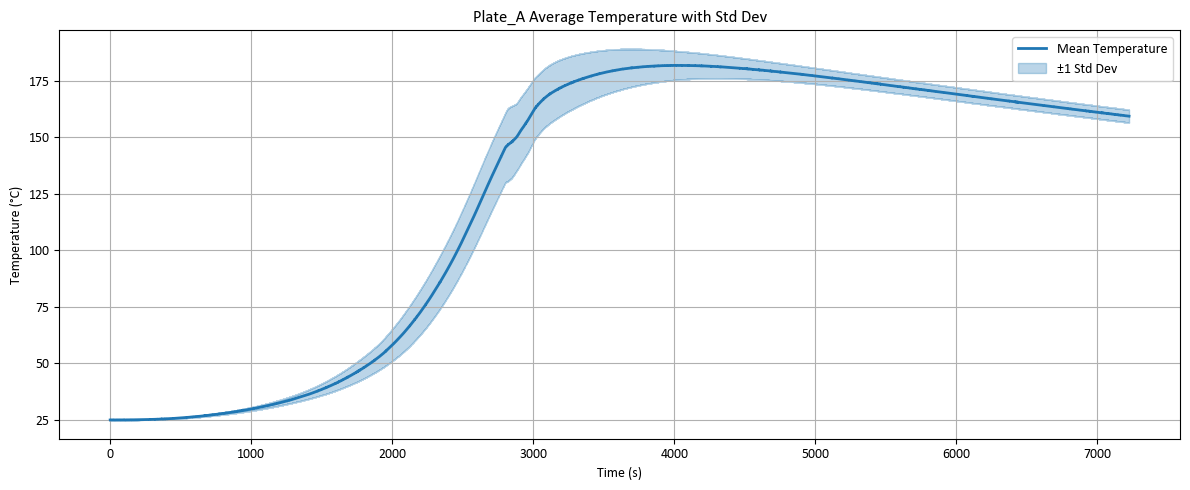

Saved Plate_Temperature_Figures_HT-B\Plate_H_Temperature.png


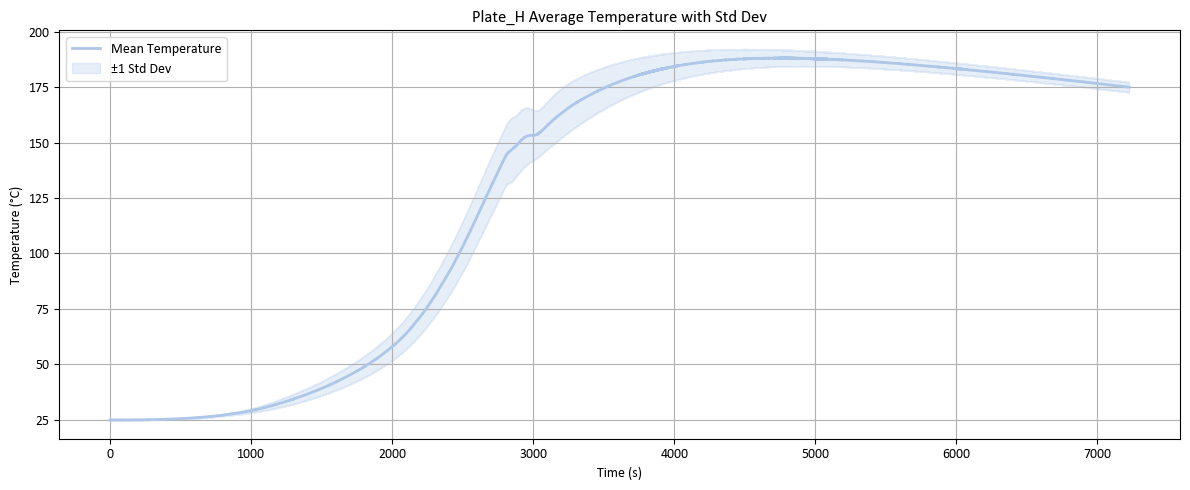

Saved Plate_Temperature_Figures_HT-B\Plate_G_Temperature.png


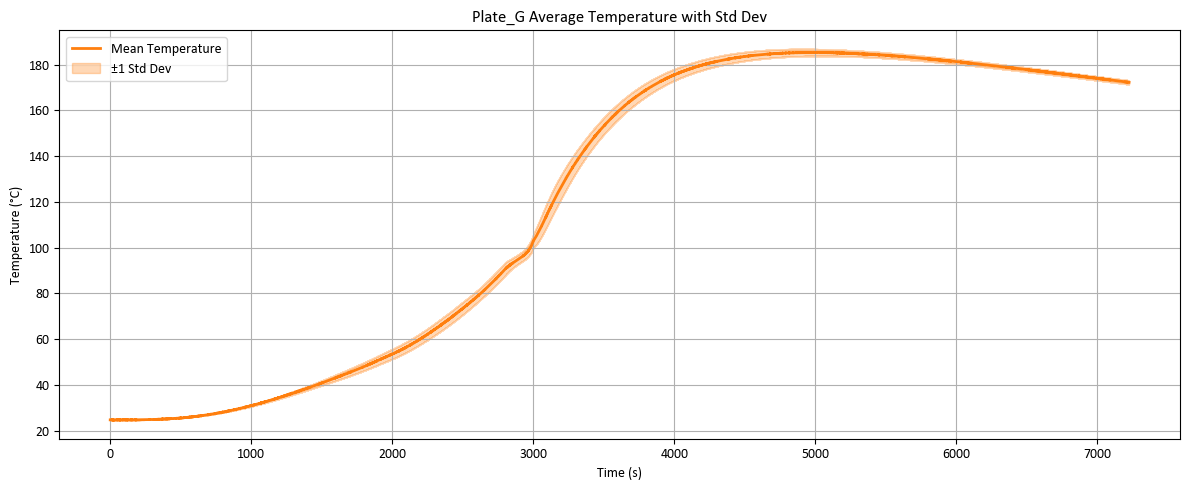

Saved Plate_Temperature_Figures_HT-B\Plate_J_Temperature.png


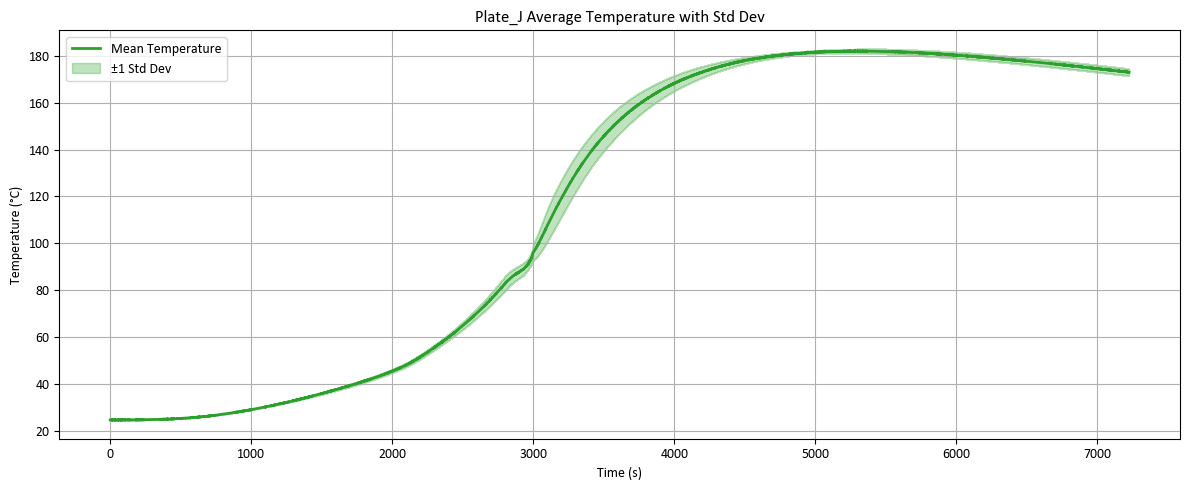

Saved Plate_Temperature_Figures_HT-B\Plate_I_Temperature.png


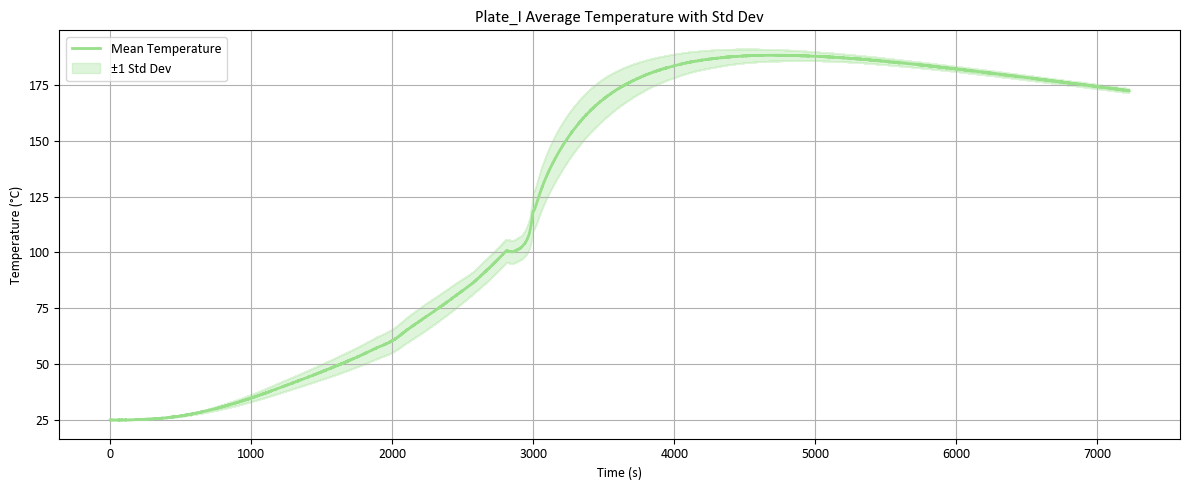

Saved Plate_Temperature_Figures_HT-B\Plate_B_Temperature.png


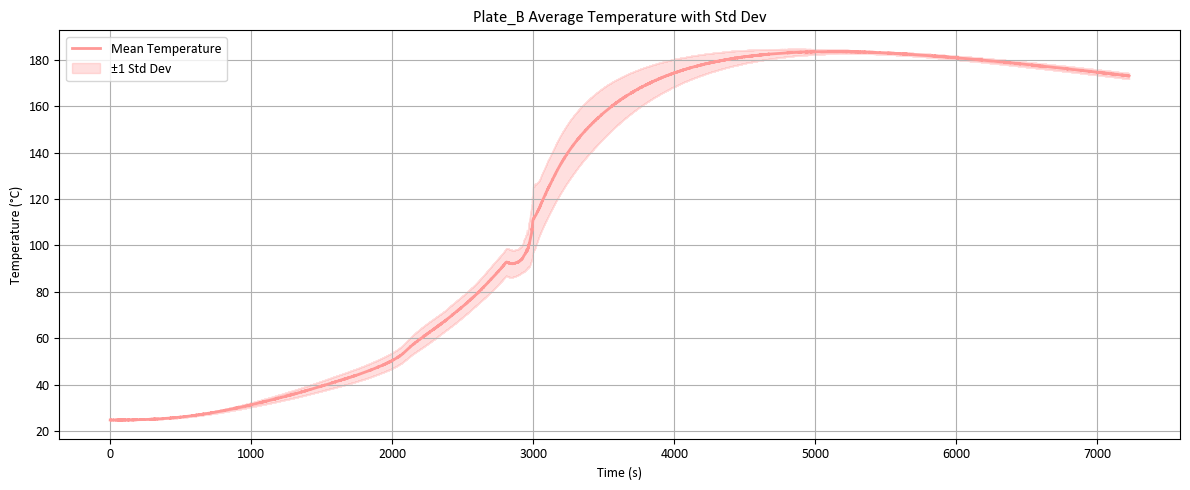

Saved Plate_Temperature_Figures_HT-B\Plate_E_Temperature.png


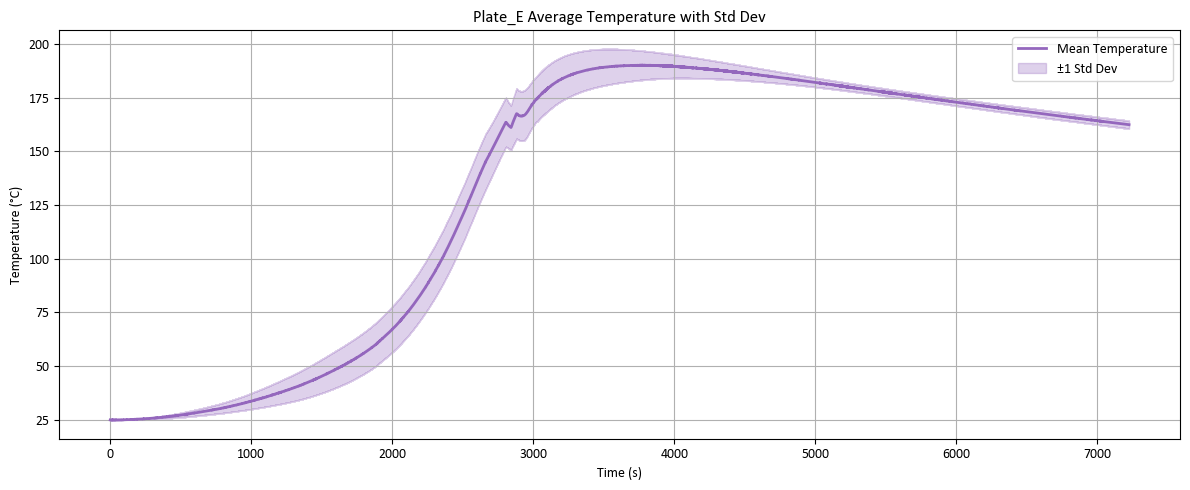

Saved Plate_Temperature_Figures_HT-B\Plate_D_Temperature.png


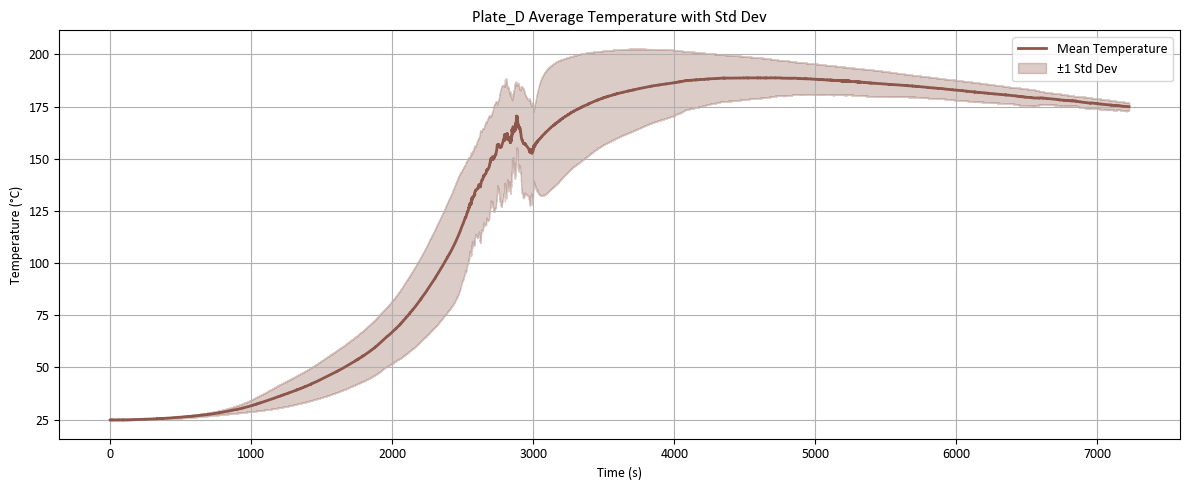

Saved Plate_Temperature_Figures_HT-B\Plate_C_Temperature.png


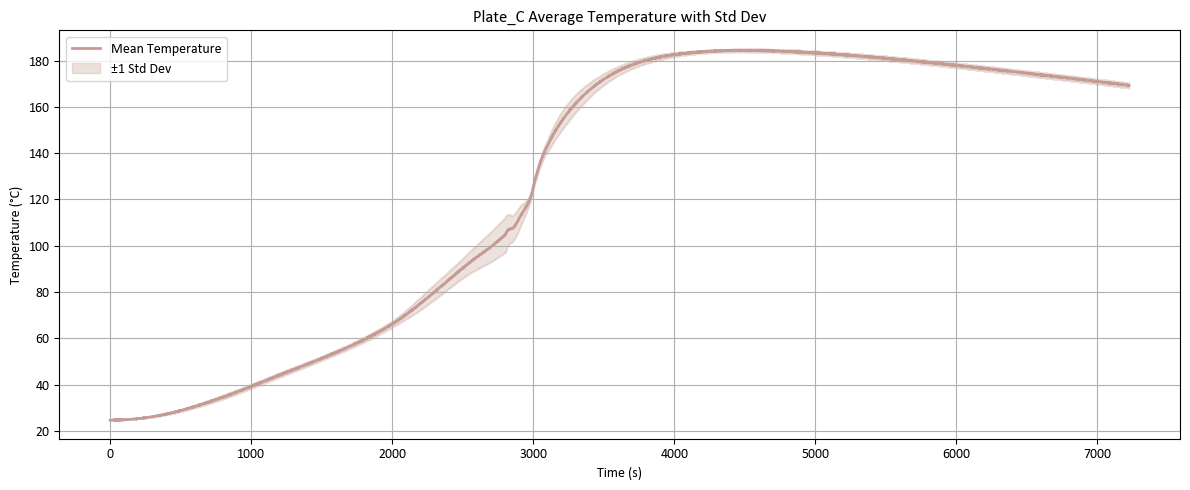

Saved Plate_Temperature_Figures_HT-B\Plate_F_Temperature.png


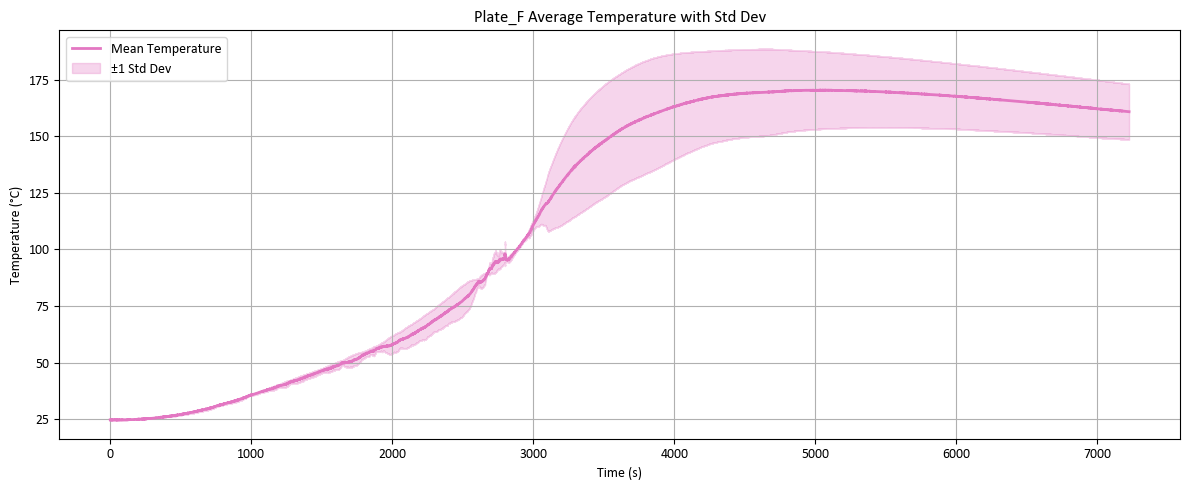

Saved Plate_Temperature_Figures_HT-B\Heater_Location_Temperature.png


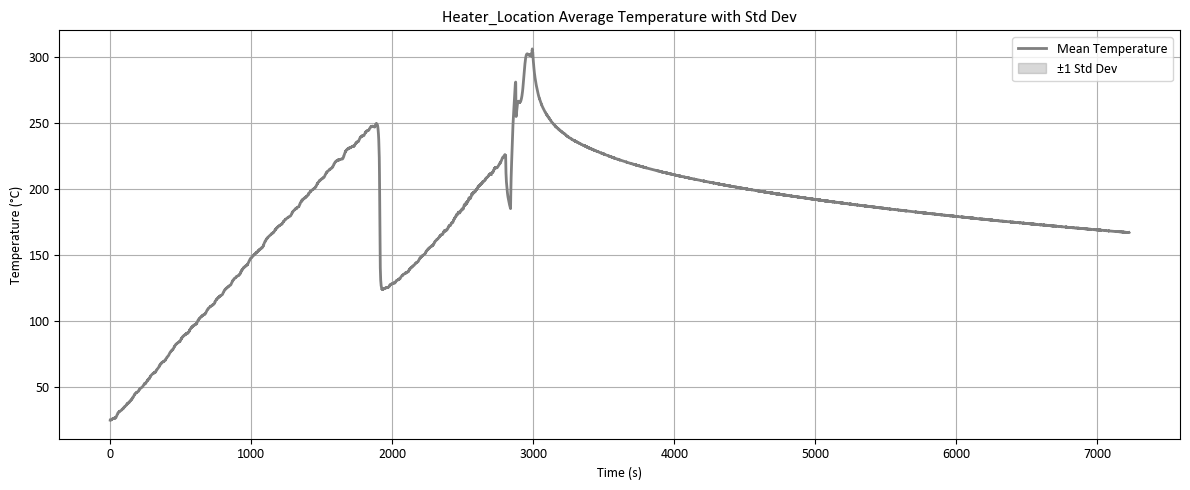

Saved Plate_Temperature_Figures_HT-B\QR_Location_Temperature.png


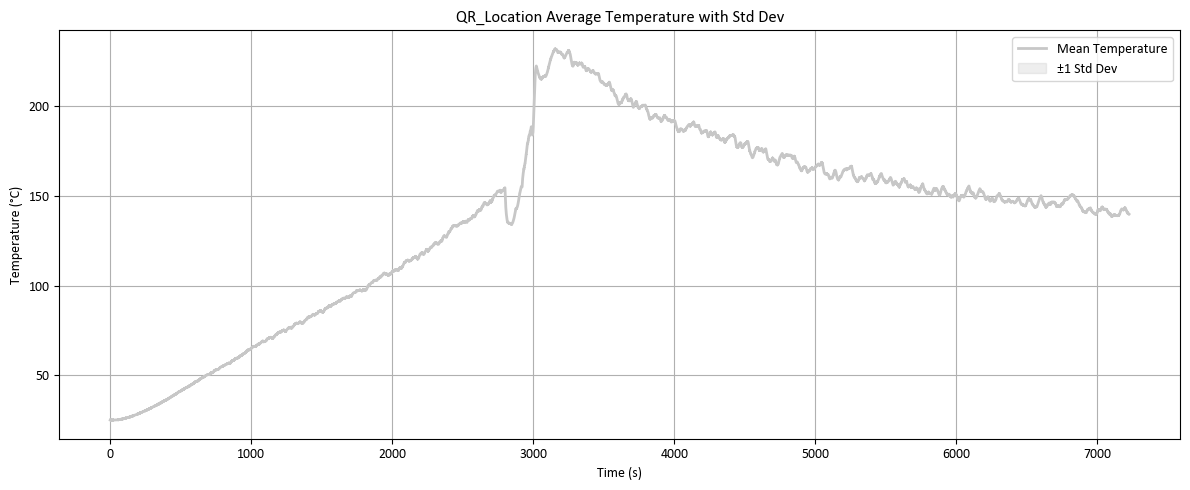

Saved Plate_Temperature_Figures_HT-B\ABM_Location_Temperature.png


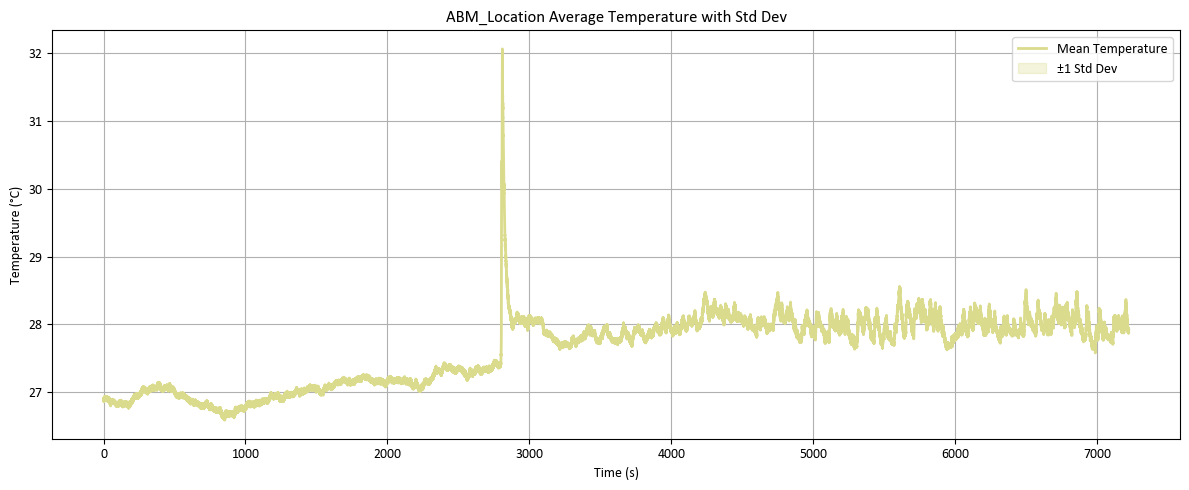

Saved Plate_Temperature_Figures_HT-B\Fixture_Ex_Nofoam_Temperature.png


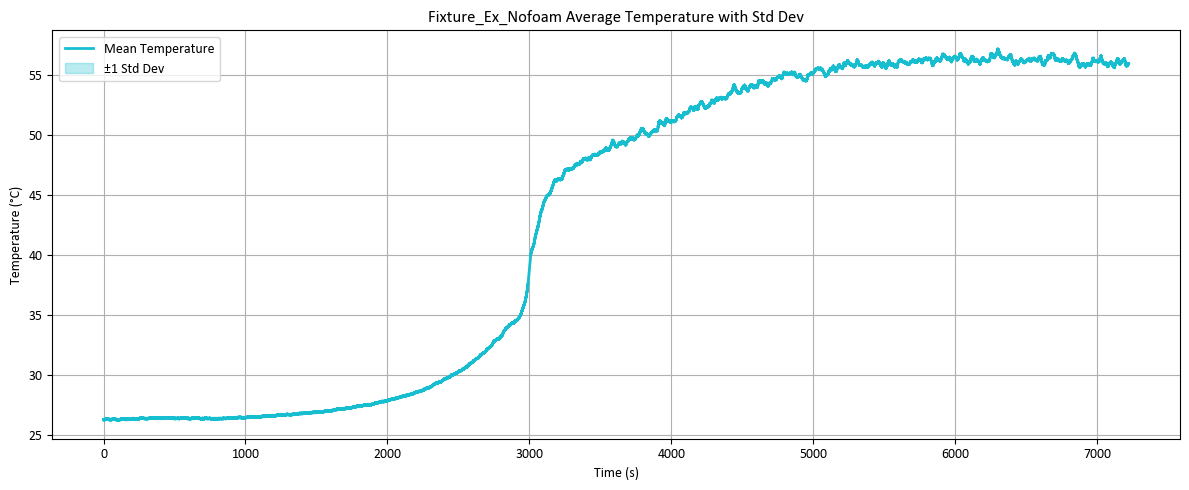

Saved Plate_Temperature_Figures_HT-B\Fixture_Ex_Foam_Temperature.png


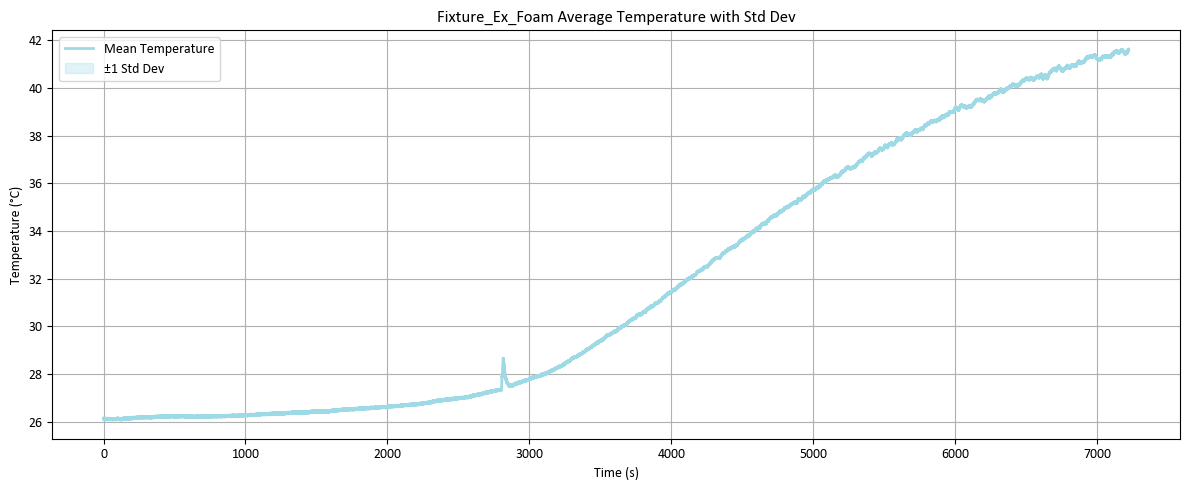

In [9]:
# -----------------------------
# Cell: Plot and Save Average Temperature per Plate
# -----------------------------

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import os

# Ensure numeric time
data1['Time_s'] = pd.to_numeric(data1['Time_s'], errors='coerce')

# Folder to save figures
save_folder = "Plate_Temperature_Figures_HT-B"
os.makedirs(save_folder, exist_ok=True)  # create folder if it doesn't exist

# Generate a colormap for the plates
plate_names = list(plate_tc_map.keys())
n_plates = len(plate_names)
cmap = cm.get_cmap('tab20', n_plates)  # tab20 has 20 distinct colors

# Assign a color to each plate
plate_colors = {plate: cmap(i) for i, plate in enumerate(plate_names)}

# Loop over each plate and plot
for plate, tcs in plate_tc_map.items():
    # Check which TCs actually exist in the dataframe
    valid_tcs = [tc for tc in tcs if tc in data1.columns]
    if len(valid_tcs) == 0:
        print(f"Skipping {plate}: No valid TCs found.")
        continue
    
    # Extract TC data
    tc_data = data1[valid_tcs]
    
    # Compute mean and standard deviation
    mean_trace = tc_data.mean(axis=1)
    std_trace = tc_data.std(axis=1)
    
    # Get the color for this plate
    color = plate_colors[plate]
    
    # Create figure for this plate
    plt.figure(figsize=(12, 5))
    
    # Plot mean trace
    plt.plot(data1['Time_s'], mean_trace, color=color, linewidth=2, label='Mean Temperature')
    
    # Plot standard deviation band
    plt.fill_between(
        data1['Time_s'],
        mean_trace - std_trace,
        mean_trace + std_trace,
        color=color,
        alpha=0.3,
        label='±1 Std Dev'
    )
    
    plt.title(f'{plate} Average Temperature with Std Dev')
    plt.xlabel('Time (s)')
    plt.ylabel('Temperature (°C)')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    
    # Save figure to folder
    save_path = os.path.join(save_folder, f"{plate}_Temperature.png")
    plt.savefig(save_path, dpi=300)
    print(f"Saved {save_path}")
    
    # Optionally show the figure
    plt.show()

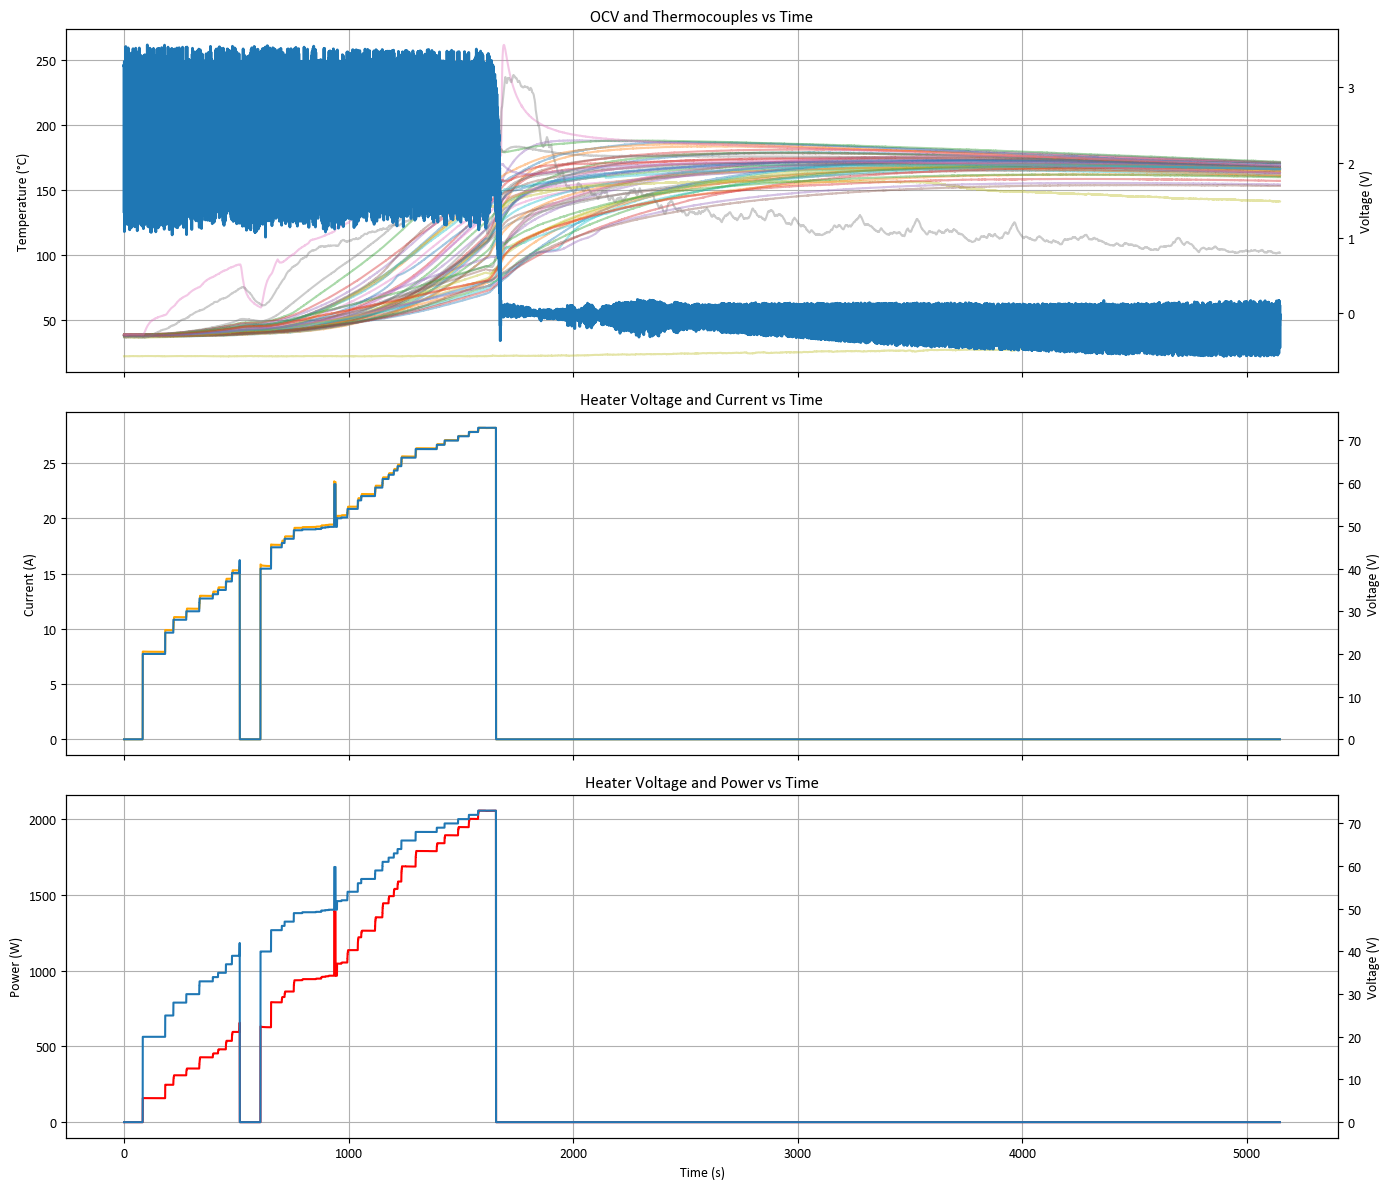

In [12]:
'''
# -----------------------------
# Cell: Three-Panel Plot (Voltages on Right Axis), Round 2
# -----------------------------

import matplotlib.pyplot as plt
%matplotlib inline

# Ensure numeric time
data1['Time_s'] = pd.to_numeric(data1['Time_s'], errors='coerce')

# Identify thermocouple columns (exclude non-temp TC columns if needed)
tc_cols = [col for col in data1.columns if col.startswith('TC')]

# Create figure
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# ============================================================
# Panel 1: OCV (right axis) + All TCs (left axis)
# ============================================================

ax1_left = axes[0]
ax1_right = ax1_left.twinx()

# Left axis → TCs
for tc in tc_cols:
    ax1_left.plot(data1['Time_s'], data1[tc], alpha=0.4)

ax1_left.set_ylabel('Temperature (°C)')
ax1_left.set_title('OCV and Thermocouples vs Time')
ax1_left.grid(True)

# Right axis → OCV
ax1_right.plot(data1['Time_s'], data1['OCV'], linewidth=2, label='OCV')
ax1_right.set_ylabel('Voltage (V)')


# ============================================================
# Panel 2: Heater Current (left) + Heater Voltage (right)
# ============================================================

ax2_left = axes[1]
ax2_right = ax2_left.twinx()

# Left axis → Current
ax2_left.plot(data1['Time_s'], data1['Heater_A'], label='Heater Current',color='orange')
ax2_left.set_ylabel('Current (A)')
ax2_left.set_title('Heater Voltage and Current vs Time')
ax2_left.grid(True)

# Right axis → Voltage
ax2_right.plot(data1['Time_s'], data1['Heater_V'], label='Heater Voltage')
ax2_right.set_ylabel('Voltage (V)')


# ============================================================
# Panel 3: Heater Power (left) + Heater Voltage (right)
# ============================================================

ax3_left = axes[2]
ax3_right = ax3_left.twinx()

# Left axis → Power
ax3_left.plot(data1['Time_s'], data1['Heater_W'], label='Heater Power',color='r')
ax3_left.set_ylabel('Power (W)')
ax3_left.set_title('Heater Voltage and Power vs Time')
ax3_left.grid(True)

# Right axis → Voltage
ax3_right.plot(data1['Time_s'], data1['Heater_V'], label='Heater Voltage')
ax3_right.set_ylabel('Voltage (V)')

axes[2].set_xlabel('Time (s)')

plt.tight_layout()
plt.show()
'''

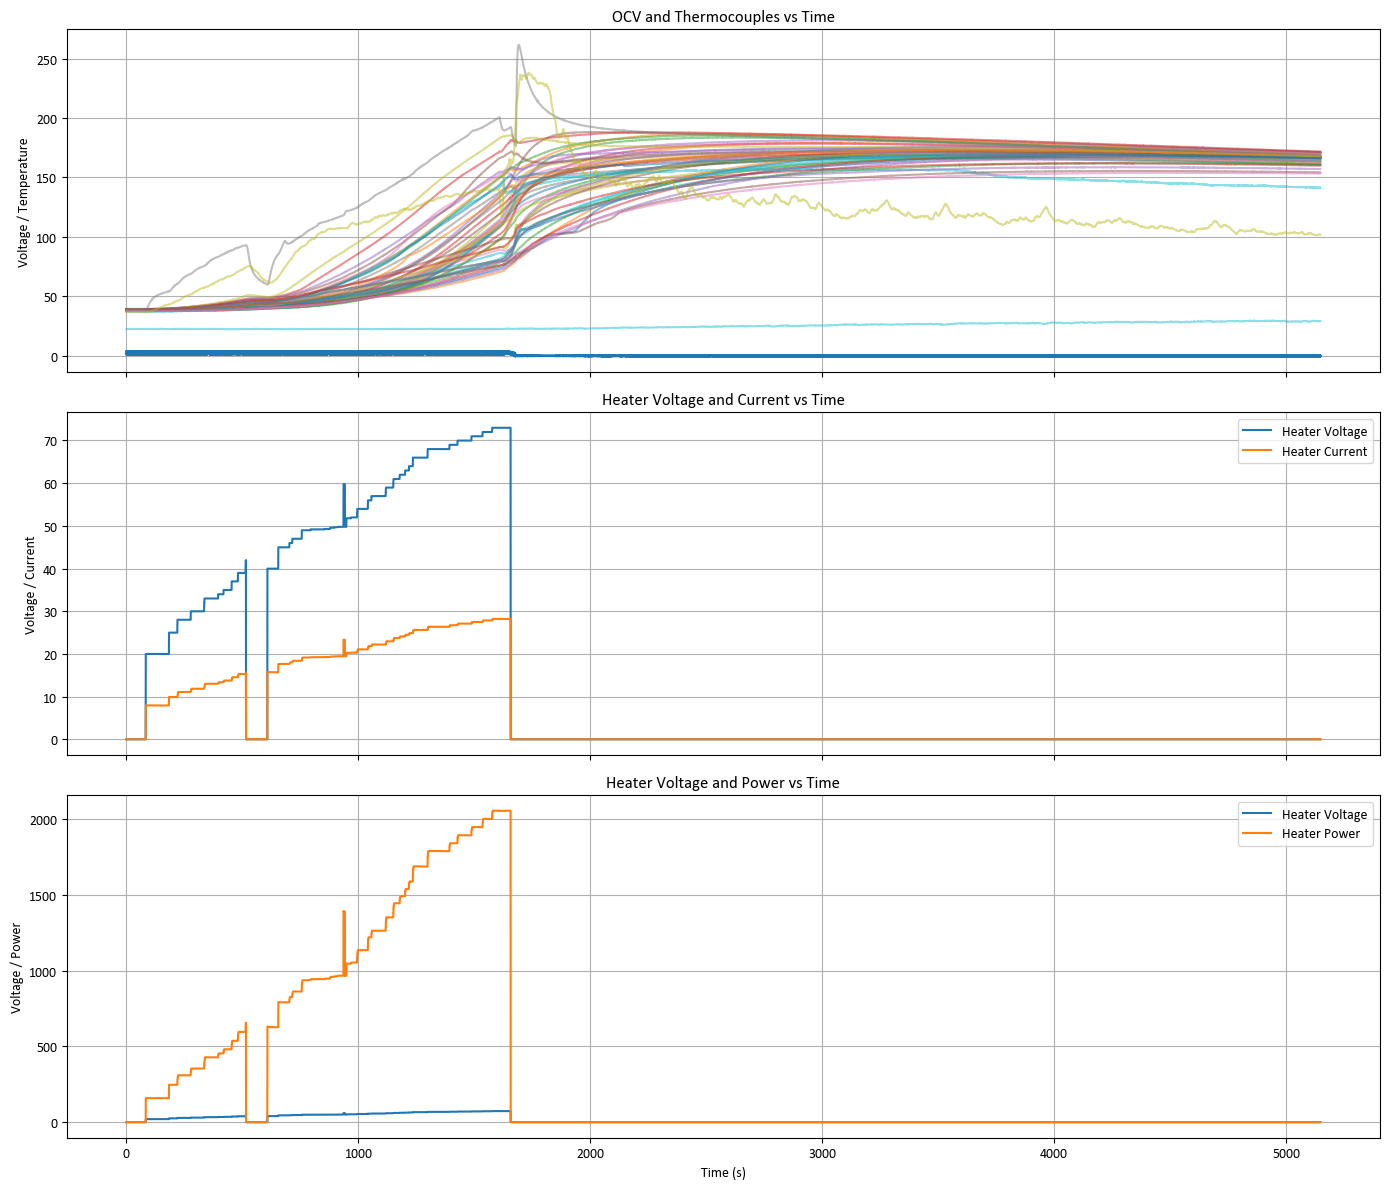

In [7]:
# -----------------------------
# Cell: Three-Panel Plot, Round1
# -----------------------------

import matplotlib.pyplot as plt
%matplotlib inline
# Ensure numeric time
data1['Time_s'] = pd.to_numeric(data1['Time_s'], errors='coerce')

# Identify all thermocouple columns
tc_cols = [col for col in data1.columns if col.startswith('TC')]

# Create figure
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# -----------------------------
# Panel 1: OCV + All TCs
# -----------------------------
axes[0].plot(data1['Time_s'], data1['OCV'], linewidth=2, label='OCV')

for tc in tc_cols:
    axes[0].plot(data1['Time_s'], data1[tc], alpha=0.5)

axes[0].set_ylabel('Voltage / Temperature')
axes[0].set_title('OCV and Thermocouples vs Time')
axes[0].grid(True)

# -----------------------------
# Panel 2: Heater Voltage & Current
# -----------------------------
axes[1].plot(data1['Time_s'], data1['Heater_V'], label='Heater Voltage')
axes[1].plot(data1['Time_s'], data1['Heater_A'], label='Heater Current')

axes[1].set_ylabel('Voltage / Current')
axes[1].set_title('Heater Voltage and Current vs Time')
axes[1].legend()
axes[1].grid(True)

# -----------------------------
# Panel 3: Heater Voltage & Power
# -----------------------------
axes[2].plot(data1['Time_s'], data1['Heater_V'], label='Heater Voltage')
axes[2].plot(data1['Time_s'], data1['Heater_W'], label='Heater Power')

axes[2].set_xlabel('Time (s)')
axes[2].set_ylabel('Voltage / Power')
axes[2].set_title('Heater Voltage and Power vs Time')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()